# Airbnb de Nueva York

## - Carga de la base de datos

In [85]:
#IMPORTAMOS LIBRERIAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
#CARGAMOS LOS DATOS
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


## - Análisis descriptivo

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [88]:
df['number_of_reviews'].value_counts()

number_of_reviews
0      10052
1       5244
2       3465
3       2520
4       1994
       ...  
417        1
368        1
436        1
310        1
341        1
Name: count, Length: 394, dtype: int64

El dataframe posee 16 columnas y 48895 filas. 6 columnas corresponden a texto.

La variable name solo falta en 16 filas y host_name falta en 21

Las variables last_review y reviews_per_month faltan en 10052, un 20.6%, lo cual coincide con las propiedades que tiene 0 reviews.

## - Eliminación de duplicados y de información no esencial

In [89]:
total_duplicados = df.duplicated().sum()
print(f"El número de duplicado según id es: {df['id'].duplicated().sum()}")

El número de duplicado según id es: 0


In [90]:
df['host_id'].value_counts()

host_id
219517861    327
107434423    232
30283594     121
137358866    103
16098958      96
            ... 
274307600      1
274311461      1
274321313      1
23492952       1
68119814       1
Name: count, Length: 37457, dtype: int64

In [91]:
df['name'].value_counts()

name
Hillside Hotel                                       18
Home away from home                                  17
New york Multi-unit building                         16
Brooklyn Apartment                                   12
Loft Suite @ The Box House Hotel                     11
                                                     ..
Charming one bedroom - newly renovated rowhouse       1
Affordable room in Bushwick/East Williamsburg         1
Sunny Studio at Historical Neighborhood               1
43rd St. Time Square-cozy single bed                  1
Trendy duplex in the very heart of Hell's Kitchen     1
Name: count, Length: 47905, dtype: int64

In [92]:
resultado = df[df['name'] == 'Home away from home']
print(resultado)

             id                 name    host_id host_name neighbourhood_group  \
16309  13125243  Home away from home   46087238   Michion              Queens   
16522  13238321  Home away from home   40976536      Jeff           Manhattan   
24723  19856899  Home away from home   67739226     Vipul           Manhattan   
25100  20111316  Home away from home   15758568      Mike            Brooklyn   
29362  22517063  Home away from home  122283834       Eve              Queens   
30933  23963981  Home away from home  180208872     Ketia            Brooklyn   
33618  26604019  Home away from home   40398107      Joey            Brooklyn   
35636  28291780  Home away from home  213660495     Jamie              Queens   
36126  28716187  Home away from home  216611306       Eme              Queens   
36883  29316421  Home away from home  216738370      Mary           Manhattan   
36909  29338253  Home away from home  221022609     Lexus            Brooklyn   
37535  29780690  Home away f

No hay registros duplicados por id.

Se verificó además que hay anfitriones (host_id) que tienen hasta 327 publicaciones, pero no se consideran duplicados.

Hay nombres de lugares que están publicados hasta 18 veces. Tampoco son duplicados como el caso de "Home away from home", elegido por 17 diferentes personas de diferentes lugares.

In [93]:
df = df.drop(["id", "name", "host_name", "last_review", "reviews_per_month"], axis = 1)
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


Se eliminaron las columnas redundantes y las que carecían de mucha información.

## - Análisis de variables categóricas

<Axes: xlabel='neighbourhood_group', ylabel='count'>

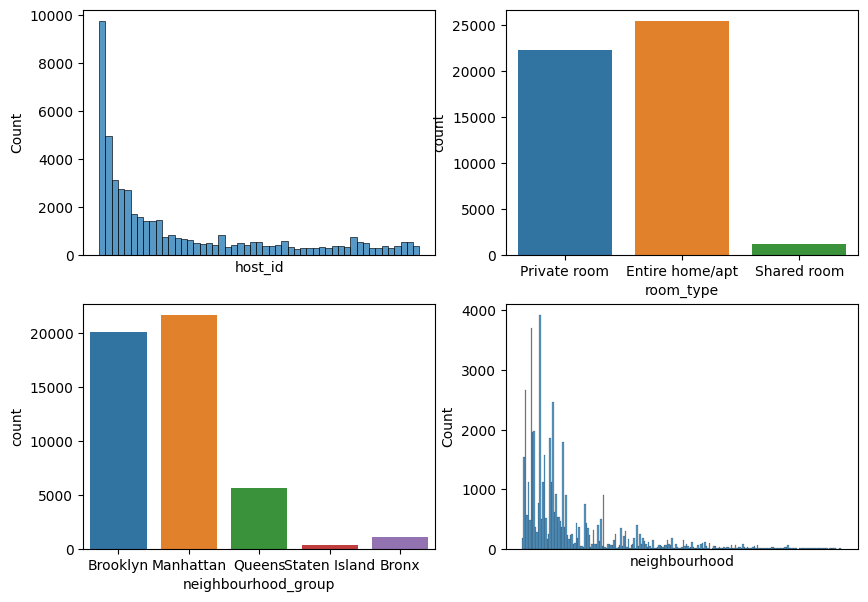

In [94]:
fig, axis = plt.subplots(2, 2, figsize=(10, 7))

sns.histplot(ax = axis[0,0], data = df, x = "host_id").set_xticks([])
#sns.countplot(ax = axis[0,0], data=df, x='host_id')
sns.countplot(ax = axis[0,1], data=df, x='room_type', hue ='room_type')
sns.histplot(ax = axis[1,1], data = df, x = "neighbourhood").set_xticks([])
sns.countplot(ax = axis[1,0], data=df, x='neighbourhood_group', hue ='neighbourhood_group')



In [95]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [96]:
manhattan_df = df[df['neighbourhood_group'] == 'Manhattan']
top_vecindario = manhattan_df['neighbourhood'].value_counts().idxmax()
total_ofertas = manhattan_df['neighbourhood'].value_counts().max()

print(f"El vecindario con más oferta en Manhattan es {top_vecindario} con {total_ofertas} alojamientos.")

El vecindario con más oferta en Manhattan es Harlem con 2658 alojamientos.


<Axes: xlabel='neighbourhood_group', ylabel='count'>

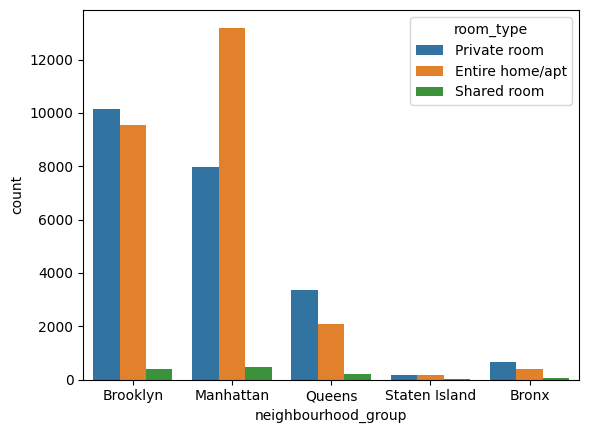

In [97]:
sns.countplot(data = df, x = "neighbourhood_group", hue = "room_type")

En la base de datos se ofrecen en su mayoría de casas enteras y habitaciones privadas; en menor proporción cuartos compartidos.

Los barrios que dominan la oferta son Manhattan y Brooklyn, Queens representa cerca de la cuarta parte de cada uno de ellos y en menor proporción se observan Staten Iland y el Bronx.

La cantidad de vecindarios es muy grande, estando los 2 con más ofertas en Brooklyn y el tercero en Manhattan.

El análisis entre las variables categóricas tipo de ambiente y barrio muestra que en 4 de los 5 barrios principales domina la oferta de habitaciones privadas, siendo Manhattan es el único lugar donde hay más oferta de apartamentos completos respecto a habitaciones privadas

## - Análisis de variables numéricas

In [98]:
df.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,7.143982,112.781327
std,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,32.952519,131.622289
min,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,1.000000,0.000000
25%,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,1.000000,0.000000
50%,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.000000,227.000000
max,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,327.000000,365.000000


In [99]:
# verifiquemos cuántas propiedades tienen precio 0 para eliminarlas de DF
(df['price'] == 0).sum()

np.int64(11)

In [100]:
# Filtramos el DF para quedarnos solo con lo que NO es 0
df = df[df['price'] > 0]

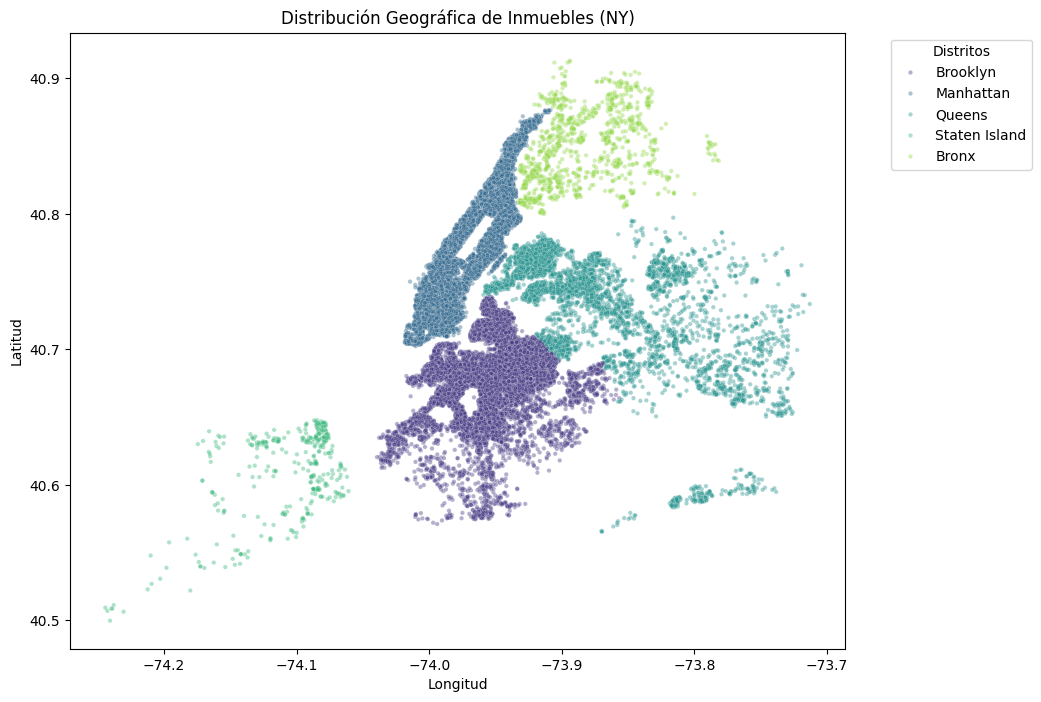

In [101]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df, x='longitude', y='latitude', 
                hue='neighbourhood_group', # Colorear por distritos
                palette='viridis',           # Paleta de colores atractiva
                s=10,                        # Tamaño de los puntos pequeño
                alpha=0.4)                   # Transparencia para ver zonas densas

plt.title('Distribución Geográfica de Inmuebles (NY)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Distritos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

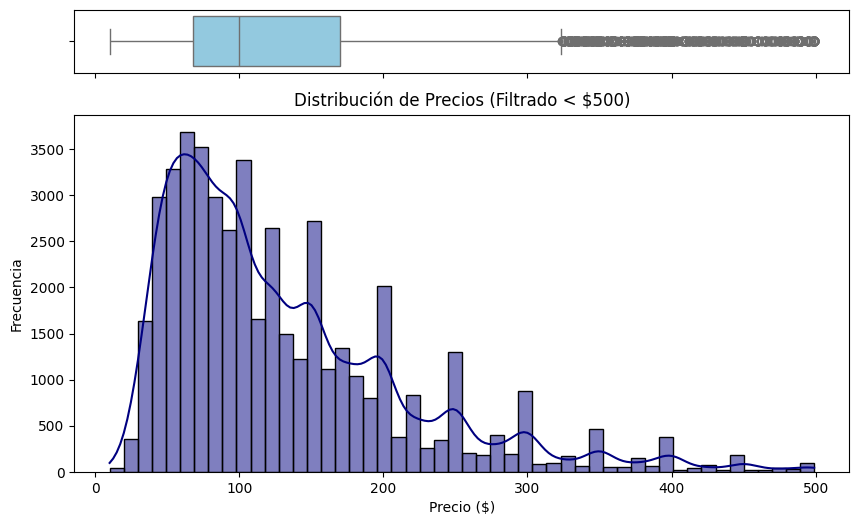

In [102]:
df_filtrado = df[df['price'] < 500]

f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

sns.boxplot(data=df_filtrado, x="price", ax=ax_box, color="skyblue")
ax_box.set(xlabel='') # Quitamos el nombre del eje X arriba

sns.histplot(data=df_filtrado, x="price", kde=True, ax=ax_hist, color="navy", bins=50)

plt.title('Distribución de Precios (Filtrado < $500)')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.show()

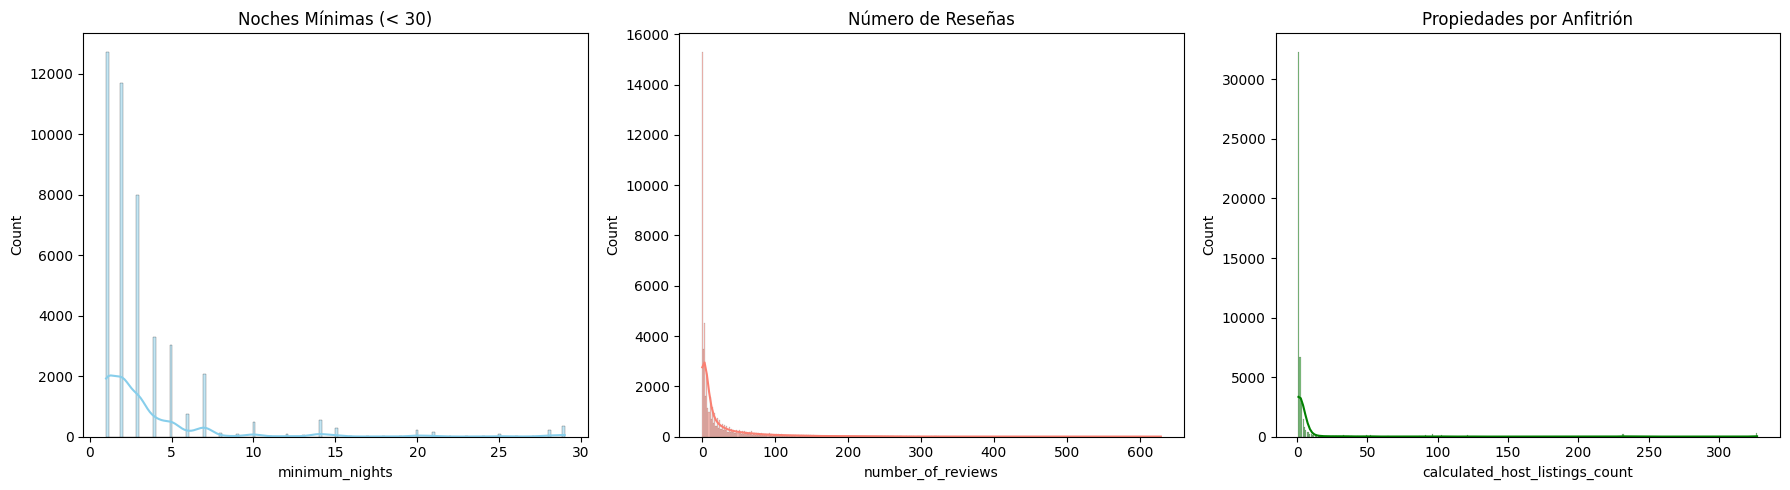

In [103]:
fig, axis = plt.subplots(1, 3, figsize=(18, 5))

# Filtro porque hay valores extremos que rompen el gráfico
sns.histplot(data=df[df['minimum_nights'] < 30], x="minimum_nights", ax=axis[0], kde=True, color="skyblue")
axis[0].set_title("Noches Mínimas (< 30)")

sns.histplot(data=df, x="number_of_reviews", ax=axis[1], kde=True, color="salmon")
axis[1].set_title("Número de Reseñas")

sns.histplot(data=df, x="calculated_host_listings_count", ax=axis[2], kde=True, color="green")
axis[2].set_title("Propiedades por Anfitrión")

plt.tight_layout()
plt.show()

Los datos de longitud y latitud se graficaron para poder ver su dispersión espacial. Se observa que en las longitudes de los barrios de Manhattan y Brooklyn se concentran una gran cantidad de datos, mientas que por latitud esa concentración no es tan notoria.

Los precios muestran una distribución asimétrica con una mediana cerca de los 100$, pero un promedio de unos 150$ y muchos valores dispersos de más de 400$.

Distrubuciones asimétricas similares se observan en el número de noches, de reseñas y propiedades por anfitrión.

# Análisis de variables categóricas y numéricas

In [104]:
precios = df.groupby('neighbourhood_group').agg({'price':['count','sum','mean','std']})
precios

price                                 
                     count      sum        mean         std
neighbourhood_group                                        
Bronx                 1090    95459   87.577064  106.725371
Brooklyn             20095  2500600  124.438915  186.896837
Manhattan            21660  4264527  196.884903  291.386838
Queens                5666   563867   99.517649  167.102155
Staten Island          373    42825  114.812332  277.620403

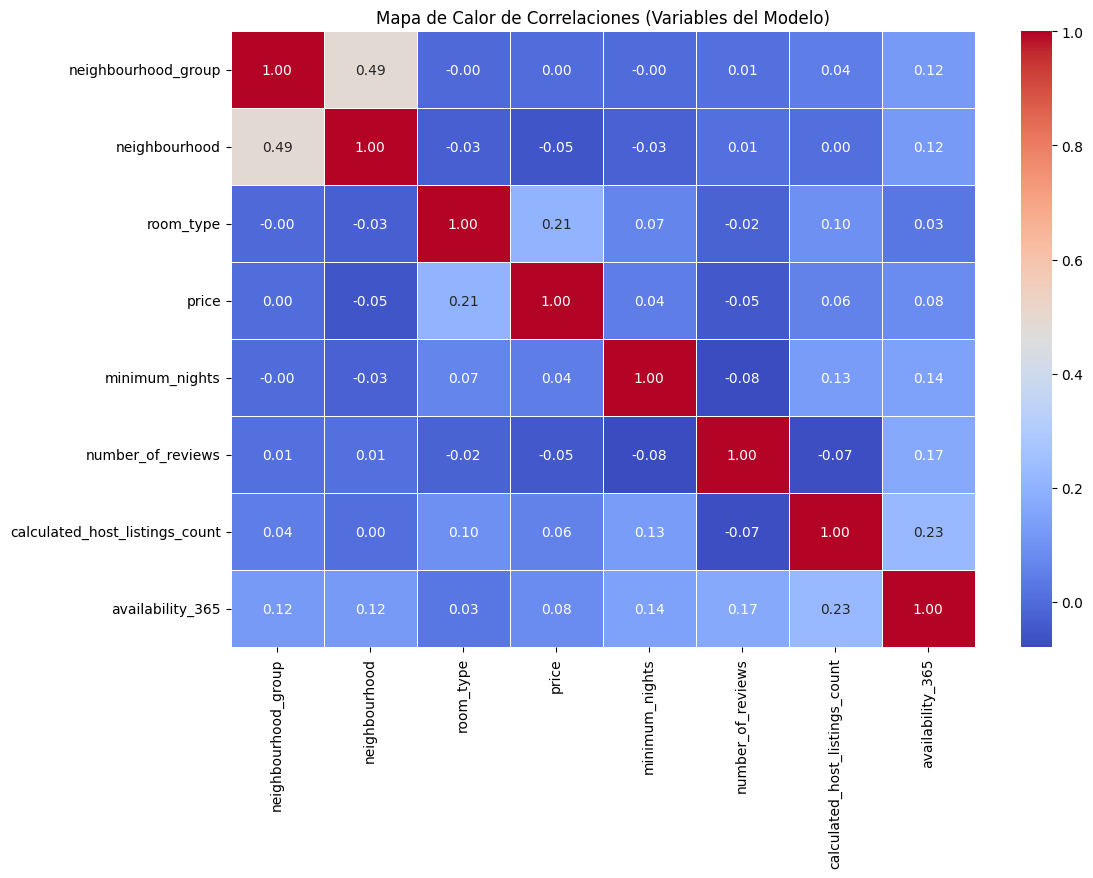

In [105]:
df["room_type"] = pd.factorize(df["room_type"])[0]
df["neighbourhood_group"] = pd.factorize(df["neighbourhood_group"])[0]
df["neighbourhood"] = pd.factorize(df["neighbourhood"])[0]

cols_interes = ["neighbourhood_group", "neighbourhood", "room_type", "price", "minimum_nights", "number_of_reviews", 
                "calculated_host_listings_count", "availability_365"]

corr_matrix = df[cols_interes].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones (Variables del Modelo)')
plt.show()

Mapa de Calor de correlaciones muestra que la variable precio, que es la que interesaría predecir, solo tiene algo de correlación es con el tipo de inmmueble (room_type). Algo de correlación también se observa entre la cantidad de inmubles de un anfitrión y la disponibilidad.

Manhattan tiene el precio promedio más alto de todos los barrios, destacado de los demás.

El Bronx tiene el precio más bajo (87$) y el resto están entre 100 y 125$.

# - Limpieza de outliers

In [106]:
price_stats = df["price"].describe()
price_stats

price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

outliers_superiores = df[df["price"] > upper_limit]
print(f"Cantidad de outliers por encima de {upper_limit}: {len(outliers_superiores)}")

porcentaje = (len(outliers_superiores) / len(df)) * 100
print(f"Representan el {porcentaje:.2f}% de los datos")



Cantidad de outliers por encima de 334.0: 2972
Representan el 6.08% de los datos


In [107]:
mn_stats = df["minimum_nights"].describe()
mn_stats

count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [108]:
mn_stats = df["minimum_nights"].describe()
mn_stats

mn_iqr = mn_stats["75%"] - mn_stats["25%"]
upper_limit = mn_stats["75%"] + 1.5 * mn_iqr
lower_limit = mn_stats["25%"] - 1.5 * mn_iqr

outliers_superiores = df[df["minimum_nights"] > upper_limit]
print(f"Cantidad de outliers por encima de {upper_limit}: {len(outliers_superiores)}")

porcentaje = (len(outliers_superiores) / len(df)) * 100
print(f"Representan el {porcentaje:.2f}% de los datos")

conteo_largas = (df['minimum_nights'] > 30).sum()
porcentaje_largas = (conteo_largas / len(df)) * 100

print()
print(f"Propiedades con estancia > 30 noches: {conteo_largas}")
print(f"Representan el {porcentaje_largas:.2f}% del dataset total")

Cantidad de outliers por encima de 11.0: 6605
Representan el 13.51% de los datos

Propiedades con estancia > 30 noches: 747
Representan el 1.53% del dataset total


Para limpiar los outliers se usará el "Sentido de Negocio" (Corte en 30 días) en lugar de usar una fórmula matemática. La mayoría de los alquileres vacacionales se dividen en estancia corta (< 30 días) y estancia larga (mensual).
Filtrar por encima de 30 días suele limpiar los valores absurdos (como esos 1250 días) sin perder los alquileres mensuales reales

In [109]:
df = df[df["minimum_nights"] <= 30]

# - Escalado de variables

In [110]:
from sklearn.preprocessing import MinMaxScaler

In [111]:
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(df[cols_interes])
df_scal = pd.DataFrame(scal_features, index = df.index, columns = cols_interes)
df_scal["price"] = df["price"]
df_scal.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,0.00,0.000000,0.0,149,0.000000,0.014308,0.015337,1.000000
1,0.25,0.004545,0.5,225,0.000000,0.071542,0.003067,0.972603
2,0.25,0.009091,0.0,150,0.068966,0.000000,0.000000,1.000000
3,0.00,0.013636,0.5,89,0.000000,0.429253,0.000000,0.531507
4,0.25,0.018182,0.5,80,0.310345,0.014308,0.000000,0.000000


# - Modelado

In [112]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

In [113]:
# Como la longitud es al oeste es negativa. Multiplicamos por -1 para que los valores sean positivos (ej: -73.98 -> 73.98).
# Esto es solo "reflejar" el mapa de Nueva York, que para el modelo matemático, no supone ningún problema.
df["longitude"] = df["longitude"] * -1

x = df.drop("price", axis = 1)
y = df["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(x_train, y_train)
ix = selection_model.get_support()
x_train_sel = pd.DataFrame(selection_model.transform(x_train), columns = x_train.columns.values[ix])
x_test_sel = pd.DataFrame(selection_model.transform(x_test), columns = x_test.columns.values[ix])

x_train_sel.head()

,host_id,number_of_reviews,calculated_host_listings_count,availability_365
0,41543076.0,1.0,1.0,0.0
1,152505727.0,5.0,1.0,105.0
2,42682752.0,2.0,3.0,0.0
3,219517861.0,0.0,327.0,347.0
4,6790993.0,0.0,1.0,77.0


# Guardado del proyecto

In [114]:
x_train_sel["price"] = list(y_train)
x_test_sel["price"] = list(y_test)
x_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
x_test_sel.to_csv("../data/processed/clean_test.csv", index = False)